In [226]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/muhammad-mohsin-1/DWDM-Assignments/refs/heads/main/water_potability.csv"

df = pd.read_csv(url)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
df.head()

Shape: (3276, 10)

Columns: ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']

First 5 rows:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [227]:
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())
print("\nBasic Statistics:")
df.describe()

Shape: (3276, 10)

Data Types:
ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

Missing Values:
ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

Duplicates: 0

Basic Statistics:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


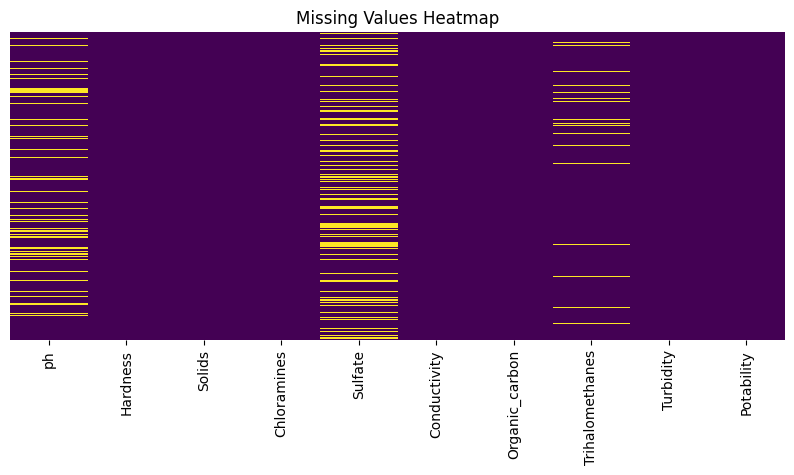

In [228]:
plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Values Heatmap")
plt.show()


In [229]:
df['ph'] = df['ph'].fillna(df['ph'].median())
df['Sulfate'] = df['Sulfate'].fillna(df['Sulfate'].median())
df['Trihalomethanes'] = df['Trihalomethanes'].fillna(df['Trihalomethanes'].median())

print("Missing values after handling:")
print(df.isnull().sum())


Missing values after handling:
ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64


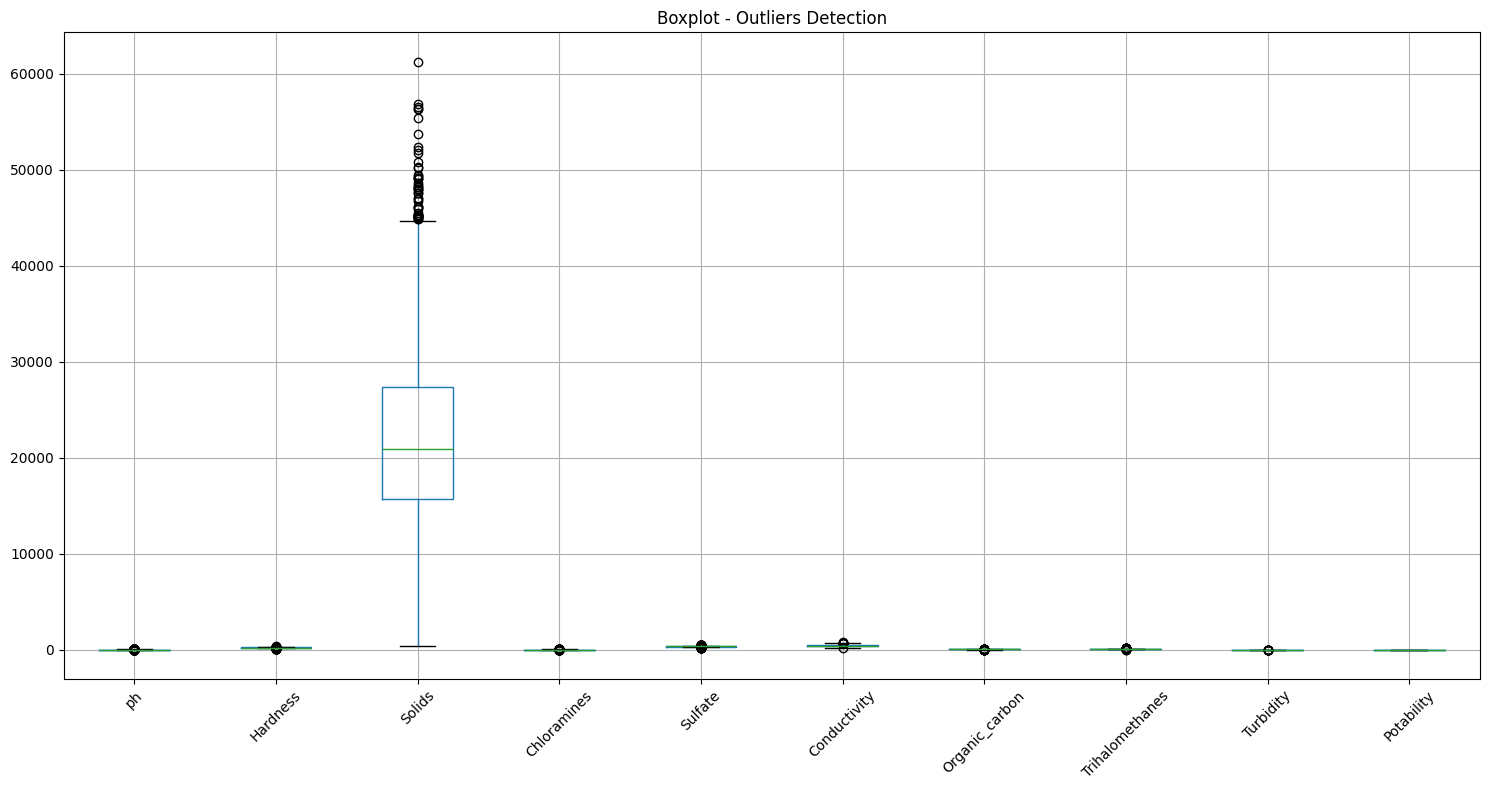

In [230]:
plt.figure(figsize=(15, 8))
df.boxplot()
plt.xticks(rotation=45)
plt.title("Boxplot - Outliers Detection")
plt.tight_layout()
plt.show()

In [231]:
cols = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
        'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df = df[(df[col] >= Q1 - 1.5*IQR) & (df[col] <= Q3 + 1.5*IQR)]

print("Shape after removing outliers:", df.shape)

Shape after removing outliers: (2657, 10)


In [232]:
df['ph_category'] = pd.cut(df['ph'],
                            bins=[0, 6.5, 8.5, 14],
                            labels=['Acidic', 'Neutral', 'Alkaline'])

print(df['ph_category'].value_counts())

ph_category
Neutral     1571
Acidic       750
Alkaline     336
Name: count, dtype: int64


In [233]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['ph_category_encoded'] = le.fit_transform(df['ph_category'])

print(df[['ph_category', 'ph_category_encoded']].head(10))

   ph_category  ph_category_encoded
0      Neutral                    2
2      Neutral                    2
3      Neutral                    2
4     Alkaline                    1
5       Acidic                    0
6     Alkaline                    1
7     Alkaline                    1
8      Neutral                    2
10     Neutral                    2
11     Neutral                    2


In [234]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols_to_scale = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
                 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("After Scaling:")
df[cols_to_scale].describe()

After Scaling:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,2657.000000,2657.000000,2657.000000,2657.000000,2657.000000,2657.000000,2657.000000,2657.000000,2657.000000
mean,0.498967,0.497786,0.479956,0.501763,0.496491,0.497027,0.497705,0.497091,0.496233
std,0.191280,0.180397,0.178727,0.180768,0.200551,0.177211,0.179045,0.184519,0.180827
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.385957,0.382980,0.347115,0.384012,0.390089,0.363718,0.373823,0.379581,0.372080
50%,0.493560,0.501167,0.459728,0.502476,0.491918,0.487008,0.493091,0.498754,0.492630
75%,0.612779,0.616880,0.599458,0.622236,0.605355,0.620288,0.623078,0.622848,0.622619
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [235]:
from sklearn.model_selection import train_test_split

X = df.drop(['Potability', 'ph_category'], axis=1)
y = df['Potability']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (2125, 10)
X_test shape: (532, 10)
y_train shape: (2125,)
y_test shape: (532,)


In [236]:
df.to_csv('cleaned_water_potability.csv', index=False)
print("Cleaned dataset saved!")
print("Final Shape:", df.shape)

Cleaned dataset saved!
Final Shape: (2657, 12)


In [237]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("Models trained successfully!")

Models trained successfully!


In [238]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

print("Decision Tree:")
print("  Accuracy :", accuracy_score(y_test, dt_pred))
print("  Precision:", precision_score(y_test, dt_pred))
print("  Recall   :", recall_score(y_test, dt_pred))
print("  F1-Score :", f1_score(y_test, dt_pred))

print("\nRandom Forest:")
print("  Accuracy :", accuracy_score(y_test, rf_pred))
print("  Precision:", precision_score(y_test, rf_pred))
print("  Recall   :", recall_score(y_test, rf_pred))
print("  F1-Score :", f1_score(y_test, rf_pred))

Decision Tree:
  Accuracy : 0.5526315789473685
  Precision: 0.37383177570093457
  Recall   : 0.43478260869565216
  F1-Score : 0.4020100502512563

Random Forest:
  Accuracy : 0.6654135338345865
  Precision: 0.5340909090909091
  Recall   : 0.2554347826086957
  F1-Score : 0.34558823529411764


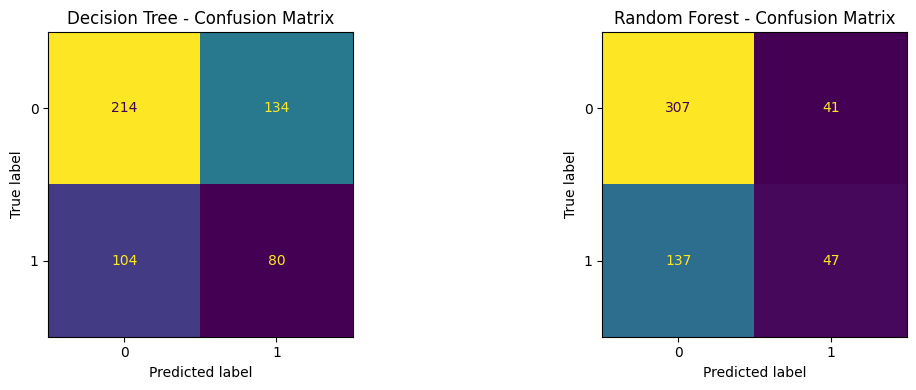

In [239]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, (name, pred) in zip(axes, [("Decision Tree", dt_pred), ("Random Forest", rf_pred)]):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f'{name} - Confusion Matrix')

plt.tight_layout()
plt.show()

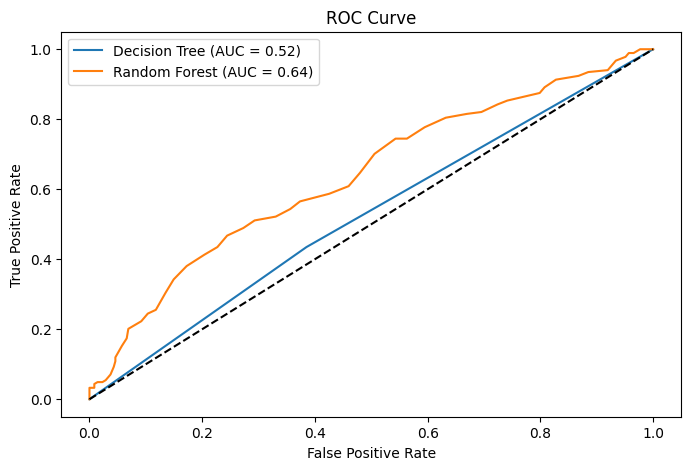

In [240]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 5))

for name, model in [("Decision Tree", dt), ("Random Forest", rf)]:
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [241]:
from sklearn.preprocessing import StandardScaler

scaler2 = StandardScaler()

cols_to_scale = ['ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate',
                 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity']

df_standard = df.copy()
df_standard[cols_to_scale] = scaler2.fit_transform(df[cols_to_scale])

print("After Standardization:")
df_standard[cols_to_scale].describe()

After Standardization:


,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity
count,2.657000e+03,2.657000e+03,2.657000e+03,2.657000e+03,2.657000e+03,2.657000e+03,2.657000e+03,2.657000e+03,2.657000e+03
mean,-2.232981e-16,-1.952187e-16,-3.690436e-16,-8.557534e-17,1.524311e-16,-2.339951e-16,1.377228e-16,-2.112641e-16,5.081036e-17
std,1.000188e+00,1.000188e+00,1.000188e+00,1.000188e+00,1.000188e+00,1.000188e+00,1.000188e+00,1.000188e+00,1.000188e+00
min,-2.609053e+00,-2.759914e+00,-2.685915e+00,-2.776256e+00,-2.476098e+00,-2.805253e+00,-2.780292e+00,-2.694492e+00,-2.744760e+00
25%,-5.909160e-01,-6.365241e-01,-7.434051e-01,-6.515155e-01,-5.306458e-01,-7.524066e-01,-6.920342e-01,-6.369675e-01,-6.867132e-01
50%,-2.826991e-02,1.874906e-02,-1.132029e-01,3.947738e-03,-2.280556e-02,-5.654853e-02,-2.577660e-02,9.013743e-03,-1.992509e-02
75%,5.951158e-01,6.603029e-01,6.687477e-01,6.665796e-01,5.429267e-01,6.956958e-01,7.003650e-01,6.816639e-01,6.990652e-01
max,2.619858e+00,2.784467e+00,2.910249e+00,2.756749e+00,2.511102e+00,2.838814e+00,2.805934e+00,2.726026e+00,2.786435e+00


**Assignment_4 Start Here**

In [242]:
df_reg = pd.read_csv('cleaned_water_potability.csv')

X_reg = df_reg.drop(['Sulfate', 'Potability', 'ph_category', 'ph_category_encoded'], axis=1)
y_reg = df_reg['Sulfate']

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42)

print("X_train:", X_train_r.shape)
print("X_test:", X_test_r.shape)

X_train: (2125, 8)
X_test: (532, 8)


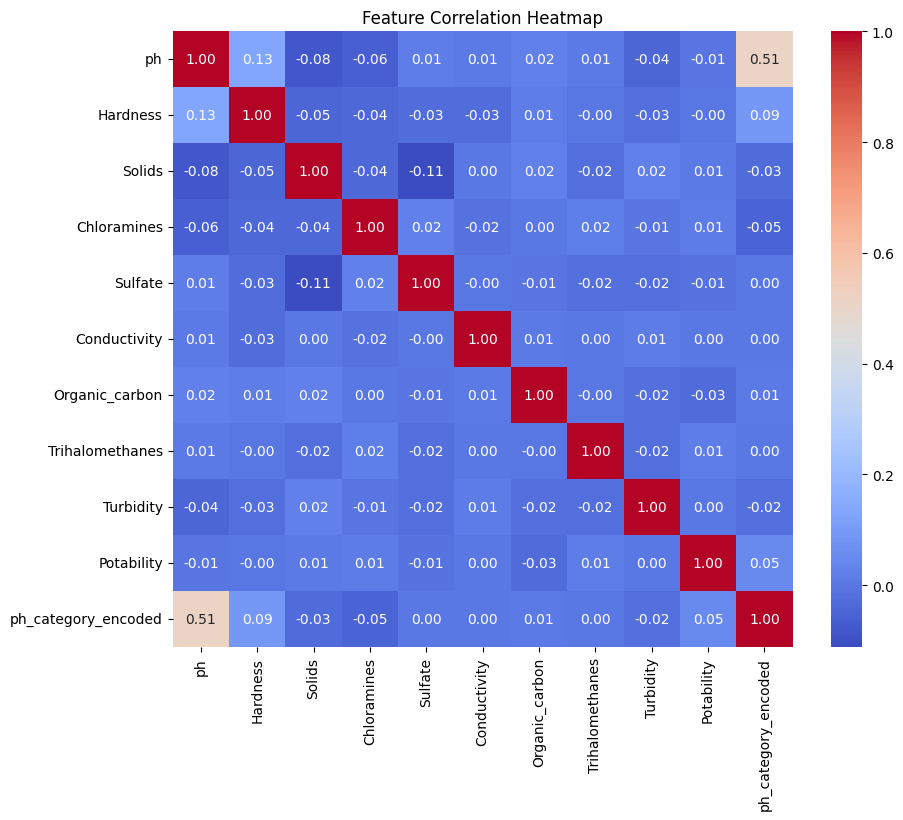

In [243]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_reg.select_dtypes(include=np.number).corr(),
            annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Heatmap")
plt.show()

In [244]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

lr = LinearRegression()
dtr = DecisionTreeRegressor(random_state=42)
rfr = RandomForestRegressor(n_estimators=100, random_state=42)

lr.fit(X_train_r, y_train_r)
dtr.fit(X_train_r, y_train_r)
rfr.fit(X_train_r, y_train_r)

print("All 3 models trained successfully!")

All 3 models trained successfully!


In [245]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

for name, model in [("Linear Regression", lr),
                     ("Decision Tree", dtr),
                     ("Random Forest", rfr)]:
    y_pred = model.predict(X_test_r)
    rmse = np.sqrt(mean_squared_error(y_test_r, y_pred))
    mae = mean_absolute_error(y_test_r, y_pred)
    r2 = r2_score(y_test_r, y_pred)

    print(f"\n{name}:")
    print(f"  RMSE : {rmse:.4f}")
    print(f"  MAE  : {mae:.4f}")
    print(f"  R2   : {r2:.4f}")


Linear Regression:
  RMSE : 0.2028
  MAE  : 0.1489
  R2   : 0.0118

Decision Tree:
  RMSE : 0.3029
  MAE  : 0.2342
  R2   : -1.2058

Random Forest:
  RMSE : 0.2057
  MAE  : 0.1558
  R2   : -0.0166


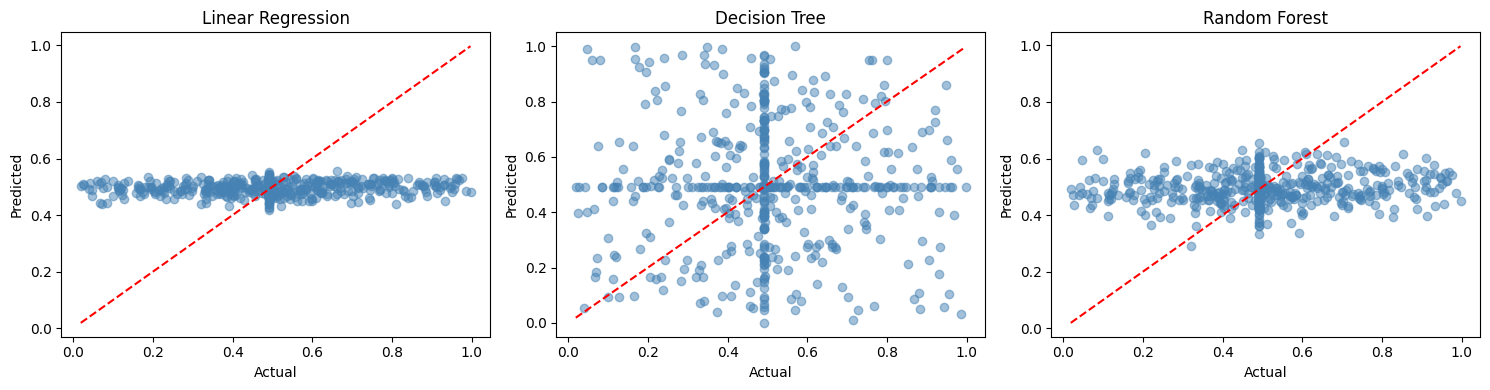

In [246]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, [("Linear Regression", lr),
                                      ("Decision Tree", dtr),
                                      ("Random Forest", rfr)]):
    y_pred = model.predict(X_test_r)
    ax.scatter(y_test_r, y_pred, alpha=0.5, color='steelblue')
    ax.plot([y_test_r.min(), y_test_r.max()],
            [y_test_r.min(), y_test_r.max()], 'r--')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.set_title(name)

plt.tight_layout()
plt.show()